In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/AI_in_Finance_Project/us_920101-200731.csv'

reader = pd.read_csv(
    file_path,
    compression='gzip',   # or 'gzip'
    encoding='latin1',
    chunksize=100000
)

df = next(reader)

df.head()

,PERMNO,date,EXCHCD,BIDLO,ASKHI,PRC,VOL,RET,SHROUT,OPENPRC
0,10001,1992-01-02,3,14.5,14.500,14.500,100.0,0.000000,1075.0,NaN
1,10001,1992-01-03,3,14.5,14.500,14.500,498.0,0.000000,1075.0,NaN
2,10001,1992-01-06,3,14.5,14.500,14.500,100.0,0.000000,1075.0,NaN
3,10001,1992-01-07,3,14.5,15.250,14.500,417.0,0.000000,1075.0,NaN
4,10001,1992-01-08,3,14.5,15.125,15.125,500.0,0.043103,1075.0,NaN


In [ ]:
df.shape


(100000, 10)

In [ ]:
df.describe()

,PERMNO,EXCHCD,BIDLO,ASKHI,PRC,VOL,SHROUT,OPENPRC
count,100000.000000,100000.000000,99179.000000,99179.000000,99179.000000,9.917900e+04,99971.000000,86678.000000
mean,10031.028130,2.713000,15.249957,15.802275,14.005548,6.762369e+04,12933.613648,16.577254
std,17.608543,0.640434,20.242009,20.740278,21.575610,1.825725e+05,11721.863839,21.524239
min,10001.000000,-2.000000,0.031250,0.031250,-55.750000,0.000000e+00,285.000000,0.031250
25%,10019.000000,3.000000,4.000000,4.290000,2.875000,2.500000e+03,4484.000000,5.000000
50%,10032.000000,3.000000,10.125000,10.500000,9.600000,1.420000e+04,8205.000000,10.800000
75%,10044.000000,3.000000,17.340000,18.000000,17.250000,5.810450e+04,18688.000000,18.625000
max,10064.000000,3.000000,193.800000,196.840000,195.660000,1.009777e+07,53989.000000,196.110000


In [ ]:
df['PERMNO'].nunique()

35

In [ ]:
#import pandas as pd

file_path = '/content/drive/MyDrive/AI_in_Finance_Project/us_920101-200731.csv'

reader = pd.read_csv(
    file_path,
    compression="gzip",   # or "zip"
    encoding="latin1",
    usecols=["PERMNO", "date", "SHROUT"],
    chunksize=100000
)

results = []

for chunk in reader:
    chunk["date"] = pd.to_datetime(chunk["date"], errors="coerce")
    chunk["SHROUT"] = pd.to_numeric(chunk["SHROUT"], errors="coerce")

    summary = (
        chunk.groupby("PERMNO")
        .agg(
            min_date=("date", "min"),
            max_date=("date", "max"),
            n_rows=("date", "size"),
            n_unique_shrout=("SHROUT", "nunique")
        )
        .reset_index()
    )

    results.append(summary)

# Combine all chunks
final = pd.concat(results)

# Aggregate again (because same PERMNO appears in multiple chunks)
final = (
    final.groupby("PERMNO")
    .agg(
        min_date=("min_date", "min"),
        max_date=("max_date", "max"),
        total_rows=("n_rows", "sum"),
        total_unique_shrout=("n_unique_shrout", "sum")  # approx
    )
    .reset_index()
)

print(final.head())

   PERMNO   min_date   max_date  total_rows  total_unique_shrout
0   10001 1992-01-02 2017-08-04        6448                  102
1   10002 1992-01-02 2013-02-19        5324                   85
2   10003 1992-01-02 1995-12-18        1003                    9
3   10009 1992-01-02 2000-11-06        2237                   23
4   10010 1992-01-02 1995-08-29         926                   16


In [ ]:
final.shape

(24425, 5)

In [ ]:
tmp = df[df['PERMNO'] == 10026].sort_values('date').copy()

tmp['PRC'] = tmp['PRC'].abs()
tmp['price_change'] = tmp['PRC'].pct_change()
tmp['shrout_change'] = tmp['SHROUT'].pct_change()

tmp[['date','PRC','SHROUT','price_change','shrout_change']].head(5)

,date,PRC,SHROUT,price_change,shrout_change
34641,1992-01-02,14.125,10659.0,NaN,NaN
34642,1992-01-03,14.250,10659.0,0.008850,0.0
34643,1992-01-06,12.750,10659.0,-0.105263,0.0
34644,1992-01-07,12.375,10659.0,-0.029412,0.0
34645,1992-01-08,12.500,10659.0,0.010101,0.0


In [ ]:
# Focus on large price moves (e.g., > 30%)
suspect = tmp[
    (tmp['price_change'].abs() > 0.3) |
    (tmp['shrout_change'].abs() > 0.3)
]

suspect[['date','PRC','SHROUT','price_change','shrout_change']]

,date,PRC,SHROUT,price_change,shrout_change
38174,2006-01-06,31.4,18298.0,-0.506056,1.0


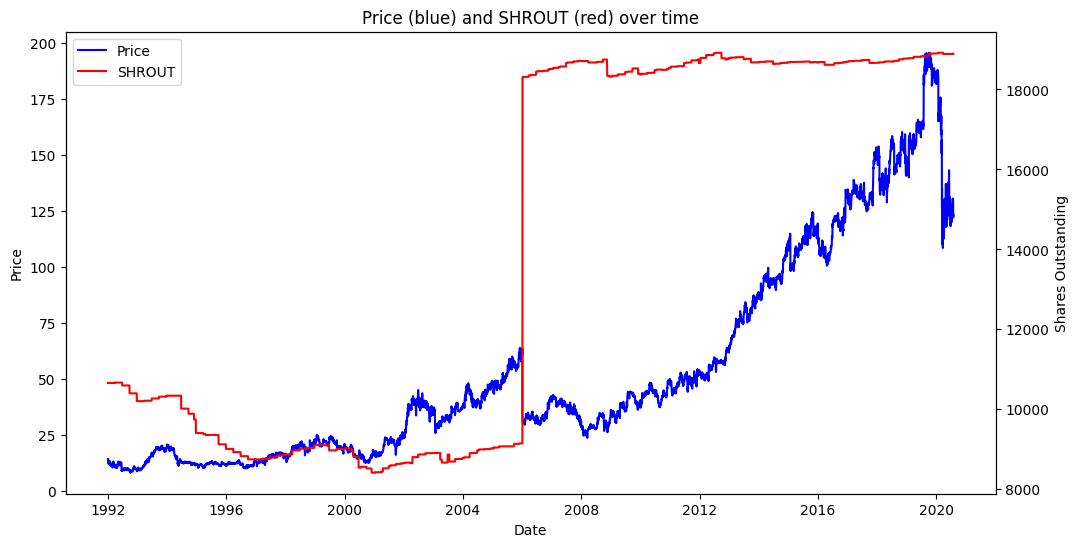

In [ ]:
import matplotlib.pyplot as plt

tmp = df[df['PERMNO'] == 10026].sort_values('date').copy()

tmp['PRC'] = tmp['PRC'].abs()
tmp['date'] = pd.to_datetime(tmp['date'])

fig, ax1 = plt.subplots(figsize=(12,6))

# Price (blue)
line1 = ax1.plot(tmp['date'], tmp['PRC'], color='blue', label='Price', linewidth=1.5)
ax1.set_xlabel('Date')
ax1.set_ylabel('Price')

# SHROUT (red)
ax2 = ax1.twinx()
line2 = ax2.plot(tmp['date'], tmp['SHROUT'], color='red', label='SHROUT', linewidth=1.5)
ax2.set_ylabel('Shares Outstanding')

# ret(Green)
#ax3 = ax1.twinx()
#line3 = ax3.plot(tmp['date'], tmp['RET'], color='red', label='Returns', linewidth=1.5)
#ax3.set_ylabel('Returns')

# Combined legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Price (blue) and SHROUT (red) over time')
plt.show()

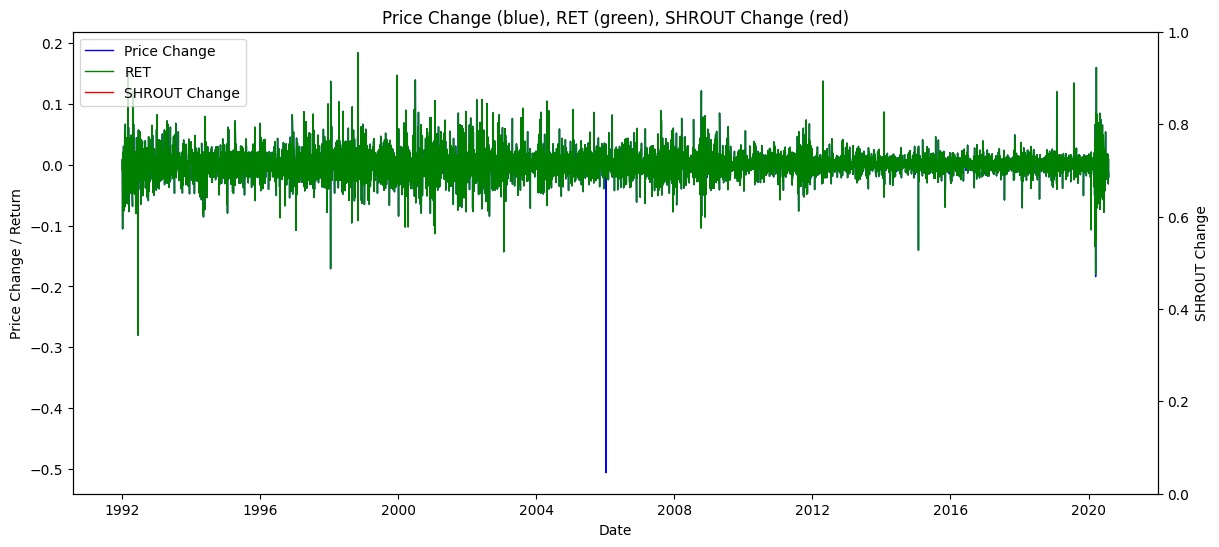

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

tmp = df[df['PERMNO'] == 10026].sort_values('date').copy()

tmp['date'] = pd.to_datetime(tmp['date'])
tmp['PRC'] = tmp['PRC'].abs()

# convert RET safely to numeric
tmp['RET'] = pd.to_numeric(tmp['RET'], errors='coerce')

# percentage changes
tmp['price_change'] = tmp['PRC'].pct_change()
tmp['shrout_change'] = tmp['SHROUT'].pct_change()

fig, ax1 = plt.subplots(figsize=(14, 6))

# Price change (blue)
line1 = ax1.plot(tmp['date'], tmp['price_change'], color='blue', label='Price Change', linewidth=1)
ax1.set_xlabel('Date')
ax1.set_ylabel('Price Change / Return')

# RET (green)
line2 = ax1.plot(tmp['date'], tmp['RET'], color='green', label='RET', linewidth=1)

# SHROUT change (red) on second axis
ax2 = ax1.twinx()
#line3 = ax2.plot(tmp['date'], tmp['shrout_change'], color='red', label='SHROUT Change', linewidth=1)
ax2.set_ylabel('SHROUT Change')

# Combined legend
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Price Change (blue), RET (green), SHROUT Change (red)')
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# --- basic cleaning ---
df = df.copy()
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["PERMNO"] = df["PERMNO"].astype(str)

for col in ["PRC", "ASKHI", "BIDLO", "SHROUT"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").abs()

df["RET"] = pd.to_numeric(df["RET"], errors="coerce")

# sort properly
df = df.sort_values(["PERMNO", "date"]).reset_index(drop=True)

# initialize new columns
df["adjusted_close"] = np.nan
df["adjusted_open"] = np.nan
df["adjusted_high"] = np.nan
df["adjusted_low"] = np.nan

def build_adjusted_prices(g):
    g = g.sort_values("date").copy()

    # keep only rows where RET and PRC exist
    valid = g["RET"].notna() & g["PRC"].notna() & (g["PRC"] != 0)

    # adjusted close: first close = 1, then cumprod of (1+RET)
    g.loc[valid, "adjusted_close"] = (1 + g.loc[valid, "RET"]).cumprod()
    if valid.any():
        first_idx = g.loc[valid].index[0]
        g.loc[first_idx:, "adjusted_close"] = g.loc[first_idx:, "adjusted_close"] / g.loc[first_idx, "adjusted_close"]

    # adjusted open = previous day's adjusted close
    g["adjusted_open"] = g["adjusted_close"].shift(1)
    g["adjusted_open"] = g["adjusted_open"].fillna(g["adjusted_close"])

    # scale factor from raw close to adjusted close
    scale = g["adjusted_close"] / g["PRC"]

    # adjusted high / low
    g["adjusted_high"] = g["ASKHI"] * scale
    g["adjusted_low"] = g["BIDLO"] * scale

    return g

df = (
    df.groupby("PERMNO", group_keys=False)
      .apply(build_adjusted_prices)
      .reset_index(drop=True)
)

# inspect
print(df[[
    "PERMNO", "date", "PRC", "RET",
    "adjusted_open", "adjusted_high", "adjusted_low", "adjusted_close"
]].head(10))

  PERMNO       date     PRC       RET  adjusted_open  adjusted_high  \
0  10001 1992-01-02  14.500  0.000000       1.000000       1.000000   
1  10001 1992-01-03  14.500  0.000000       1.000000       1.000000   
2  10001 1992-01-06  14.500  0.000000       1.000000       1.000000   
3  10001 1992-01-07  14.500  0.000000       1.000000       1.051724   
4  10001 1992-01-08  15.125  0.043103       1.000000       1.043103   
5  10001 1992-01-09  14.500 -0.041322       1.043103       1.000000   
6  10001 1992-01-10  14.500  0.000000       1.000000       1.000000   
7  10001 1992-01-13  14.500  0.000000       1.000000       1.000000   
8  10001 1992-01-14  14.500  0.000000       1.000000       1.000000   
9  10001 1992-01-15  15.000  0.034483       1.000000       1.051724   

   adjusted_low  adjusted_close  
0           1.0        1.000000  
1           1.0        1.000000  
2           1.0        1.000000  
3           1.0        1.000000  
4           1.0        1.043103  
5           1.

/tmp/ipykernel_4506/1211615661.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(build_adjusted_prices)


In [ ]:
df.head()

,PERMNO,date,EXCHCD,BIDLO,ASKHI,PRC,VOL,RET,SHROUT,OPENPRC,adjusted_close,adjusted_open,adjusted_high,adjusted_low
0,10001,1992-01-02,3,14.5,14.500,14.500,100.0,0.000000,1075.0,NaN,1.000000,1.0,1.000000,1.0
1,10001,1992-01-03,3,14.5,14.500,14.500,498.0,0.000000,1075.0,NaN,1.000000,1.0,1.000000,1.0
2,10001,1992-01-06,3,14.5,14.500,14.500,100.0,0.000000,1075.0,NaN,1.000000,1.0,1.000000,1.0
3,10001,1992-01-07,3,14.5,15.250,14.500,417.0,0.000000,1075.0,NaN,1.000000,1.0,1.051724,1.0
4,10001,1992-01-08,3,14.5,15.125,15.125,500.0,0.043103,1075.0,NaN,1.043103,1.0,1.043103,1.0


In [ ]:
df.to_csv("/content/drive/MyDrive/AI_in_Finance_Project/updated_file.csv", index=False)

In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/AI_in_Finance_Project/updated_file.csv"

df = pd.read_csv(file_path)

# view first few rows
df.head()

,PERMNO,date,EXCHCD,BIDLO,ASKHI,PRC,VOL,RET,SHROUT,OPENPRC,adjusted_close,adjusted_open,adjusted_high,adjusted_low
0,10001,1992-01-02,3,14.5,14.500,14.500,100.0,0.000000,1075.0,NaN,1.000000,1.0,1.000000,1.0
1,10001,1992-01-03,3,14.5,14.500,14.500,498.0,0.000000,1075.0,NaN,1.000000,1.0,1.000000,1.0
2,10001,1992-01-06,3,14.5,14.500,14.500,100.0,0.000000,1075.0,NaN,1.000000,1.0,1.000000,1.0
3,10001,1992-01-07,3,14.5,15.250,14.500,417.0,0.000000,1075.0,NaN,1.000000,1.0,1.051724,1.0
4,10001,1992-01-08,3,14.5,15.125,15.125,500.0,0.043103,1075.0,NaN,1.043103,1.0,1.043103,1.0


In [ ]:
df.shape

(100000, 14)

In [ ]:
import pandas as pd
import numpy as np
import os

input_path = "/content/drive/MyDrive/AI_in_Finance_Project/us_920101-200731.csv"
output_path = "/content/drive/MyDrive/AI_in_Finance_Project/us_920101-200731_adjusted_full.csv"
chunksize = 100_000

last_adjusted_close = {}

# force delete bad output
if os.path.exists(output_path):
    os.remove(output_path)

reader = pd.read_csv(
    input_path,
    compression="gzip",
    encoding="latin1",
    chunksize=chunksize,
    low_memory=False
)

for chunk_num, chunk in enumerate(reader, start=1):
    chunk = chunk.copy()

    chunk["PERMNO"] = pd.to_numeric(chunk["PERMNO"], errors="coerce")
    chunk["RET"] = pd.to_numeric(chunk["RET"], errors="coerce")

    for col in ["PRC", "ASKHI", "BIDLO"]:
        chunk[col] = pd.to_numeric(chunk[col], errors="coerce").abs()

    chunk["adjusted_close"] = np.nan
    chunk["adjusted_open"] = np.nan
    chunk["adjusted_high"] = np.nan
    chunk["adjusted_low"] = np.nan

    for permno, g in chunk.groupby("PERMNO", sort=False):
        idx = g.index

        prc = g["PRC"].to_numpy()
        ret = g["RET"].to_numpy()
        high = g["ASKHI"].to_numpy()
        low = g["BIDLO"].to_numpy()

        adj_close = np.full(len(g), np.nan)
        adj_open  = np.full(len(g), np.nan)
        adj_high  = np.full(len(g), np.nan)
        adj_low   = np.full(len(g), np.nan)

        prev_close = last_adjusted_close.get(permno, np.nan)

        for i in range(len(g)):
            if i == 0:
                if pd.notna(prev_close) and pd.notna(ret[i]):
                    adj_close[i] = prev_close * (1 + ret[i])
                else:
                    adj_close[i] = 1.0 if pd.notna(prc[i]) and prc[i] != 0 else np.nan
            else:
                if pd.notna(adj_close[i - 1]) and pd.notna(ret[i]):
                    adj_close[i] = adj_close[i - 1] * (1 + ret[i])

            if i == 0:
                adj_open[i] = prev_close if pd.notna(prev_close) else adj_close[i]
            else:
                adj_open[i] = adj_close[i - 1]

            if pd.notna(adj_close[i]) and pd.notna(prc[i]) and prc[i] != 0:
                scale = adj_close[i] / prc[i]
                adj_high[i] = high[i] * scale if pd.notna(high[i]) else np.nan
                adj_low[i] = low[i] * scale if pd.notna(low[i]) else np.nan

        chunk.loc[idx, "adjusted_close"] = adj_close
        chunk.loc[idx, "adjusted_open"] = adj_open
        chunk.loc[idx, "adjusted_high"] = adj_high
        chunk.loc[idx, "adjusted_low"] = adj_low

        valid_last = pd.Series(adj_close).dropna()
        if not valid_last.empty:
            last_adjusted_close[permno] = valid_last.iloc[-1]

    # write header only for first chunk
    if chunk_num == 1:
        chunk.to_csv(output_path, mode="w", header=True, index=False)
    else:
        chunk.to_csv(output_path, mode="a", header=False, index=False)

    print(f"Finished chunk {chunk_num}")

print("Done")

Finished chunk 1
Finished chunk 2
Finished chunk 3
Finished chunk 4
Finished chunk 5
Finished chunk 6
Finished chunk 7
Finished chunk 8
Finished chunk 9
Finished chunk 10
Finished chunk 11
Finished chunk 12
Finished chunk 13
Finished chunk 14
Finished chunk 15
Finished chunk 16
Finished chunk 17
Finished chunk 18
Finished chunk 19
Finished chunk 20
Finished chunk 21
Finished chunk 22
Finished chunk 23
Finished chunk 24
Finished chunk 25
Finished chunk 26
Finished chunk 27
Finished chunk 28
Finished chunk 29
Finished chunk 30
Finished chunk 31
Finished chunk 32
Finished chunk 33
Finished chunk 34
Finished chunk 35
Finished chunk 36
Finished chunk 37
Finished chunk 38
Finished chunk 39
Finished chunk 40
Finished chunk 41
Finished chunk 42
Finished chunk 43
Finished chunk 44
Finished chunk 45
Finished chunk 46
Finished chunk 47
Finished chunk 48
Finished chunk 49
Finished chunk 50
Finished chunk 51
Finished chunk 52
Finished chunk 53
Finished chunk 54
Finished chunk 55
Finished chunk 56
F

In [ ]:
with open(output_path, "r") as f:
    for _ in range(3):
        print(f.readline())

PERMNO,date,EXCHCD,BIDLO,ASKHI,PRC,VOL,RET,SHROUT,OPENPRC,adjusted_close,adjusted_open,adjusted_high,adjusted_low

10001,1992-01-02,3,14.5,14.5,14.5,100.0,0.0,1075.0,,1.0,1.0,1.0,1.0

10001,1992-01-03,3,14.5,14.5,14.5,498.0,0.0,1075.0,,1.0,1.0,1.0,1.0



In [ ]:
import pandas as pd

df = pd.read_csv(output_path, nrows=5)
print(df.head())
print(df.columns)

   PERMNO        date  EXCHCD  BIDLO   ASKHI     PRC    VOL       RET  SHROUT  \
0   10001  1992-01-02       3   14.5  14.500  14.500  100.0  0.000000  1075.0   
1   10001  1992-01-03       3   14.5  14.500  14.500  498.0  0.000000  1075.0   
2   10001  1992-01-06       3   14.5  14.500  14.500  100.0  0.000000  1075.0   
3   10001  1992-01-07       3   14.5  15.250  14.500  417.0  0.000000  1075.0   
4   10001  1992-01-08       3   14.5  15.125  15.125  500.0  0.043103  1075.0   

   OPENPRC  adjusted_close  adjusted_open  adjusted_high  adjusted_low  
0      NaN        1.000000            1.0       1.000000           1.0  
1      NaN        1.000000            1.0       1.000000           1.0  
2      NaN        1.000000            1.0       1.000000           1.0  
3      NaN        1.000000            1.0       1.051724           1.0  
4      NaN        1.043103            1.0       1.043103           1.0  
Index(['PERMNO', 'date', 'EXCHCD', 'BIDLO', 'ASKHI', 'PRC', 'VOL', 'RET',
 

In [ ]:
file_path = '/content/drive/MyDrive/AI_in_Finance_Project/us_920101-200731_adjusted_full.csv'

reader = pd.read_csv(
    file_path,
    #compression='gzip',   # or 'gzip'
    encoding='latin1',
    chunksize=100000
)

df = next(reader)

df.head(30)

,PERMNO,date,EXCHCD,BIDLO,ASKHI,PRC,VOL,RET,SHROUT,OPENPRC,adjusted_close,adjusted_open,adjusted_high,adjusted_low
0,10001,1992-01-02,3,14.50,14.500,14.500,100.0,0.000000,1075.0,NaN,1.000000,1.000000,1.000000,1.000000
1,10001,1992-01-03,3,14.50,14.500,14.500,498.0,0.000000,1075.0,NaN,1.000000,1.000000,1.000000,1.000000
2,10001,1992-01-06,3,14.50,14.500,14.500,100.0,0.000000,1075.0,NaN,1.000000,1.000000,1.000000,1.000000
3,10001,1992-01-07,3,14.50,15.250,14.500,417.0,0.000000,1075.0,NaN,1.000000,1.000000,1.051724,1.000000
4,10001,1992-01-08,3,14.50,15.125,15.125,500.0,0.043103,1075.0,NaN,1.043103,1.000000,1.043103,1.000000
5,10001,1992-01-09,3,14.50,14.500,14.500,1200.0,-0.041322,1075.0,NaN,1.000000,1.043103,1.000000,1.000000
6,10001,1992-01-10,3,14.50,14.500,14.500,150.0,0.000000,1075.0,NaN,1.000000,1.000000,1.000000,1.000000
7,10001,1992-01-13,3,14.50,14.500,14.500,1200.0,0.000000,1075.0,NaN,1.000000,1.000000,1.000000,1.000000
8,10001,1992-01-14,3,14.50,14.500,14.500,800.0,0.000000,1075.0,NaN,1.000000,1.000000,1.000000,1.000000
9,10001,1992-01-15,3,14.50,15.250,15.000,1200.0,0.034483,1075.0,NaN,1.034483,1.000000,1.051724,1.000000
